# 01 · EDA — the target over time

What this notebook settles, and nothing else:

1. **Is the target stable over time?** It is not, and the way it moves decides where the
   temporal split is cut.
2. **Why does it move?** Because it tracks delivery delay, almost one to one.

The logic lives in `src/`; this notebook calls it and tells the story. Feature exploration
is notebook `02`, not here.

> Decisions taken here are recorded as **D-08** in `docs/decisiones.md`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src import config, data
from src.features import load_spine, monthly_target_summary, split_summary

# Categorical slots 1 and 2 of the reference palette, plus recessive ink for
# grid, axes and annotations. Two series at most per figure, on one axis.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, BAND = "#0b0b0b", "#52514e", "#e8e8e6"

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": BAND,
    "grid.linewidth": 0.8,
})

spine = load_spine()
print(f"{len(spine):,} orders · prevalence {spine['y'].mean():.2%}")
split_summary(spine)

96,636 orders · prevalence 13.42%


,months,orders,positives,prevalence,first,last
split,,,,,,
train,15,64360,9458,0.146955,2017-01-05 11:56:06,2018-03-31 23:54:10
val,2,13612,1614,0.118572,2018-04-01 00:11:32,2018-05-31 23:51:24
test,3,18664,1901,0.101854,2018-06-01 00:39:55,2018-08-29 15:00:37


## 1 · The prevalence is not stable

Three blocks, cut by date. Note the prevalence column above: it falls from **14.70%** in
training to **10.19%** in test. That is not noise, and it is the reason every metric in this
project is reported next to the prevalence of the block it was measured on. A PR-AUC read
against the wrong base rate means nothing.

In [4]:
monthly = monthly_target_summary(spine)
monthly.assign(prevalence=lambda d: (d["prevalence"] * 100).round(2))

,orders,positives,prevalence
month,,,
2017-01,754,95,12.60
2017-02,1652,193,11.68
2017-03,2572,306,11.90
2017-04,2336,330,14.13
2017-05,3567,392,10.99
2017-06,3158,358,11.34
2017-07,3893,412,10.58
2017-08,4204,421,10.01
2017-09,4154,447,10.76


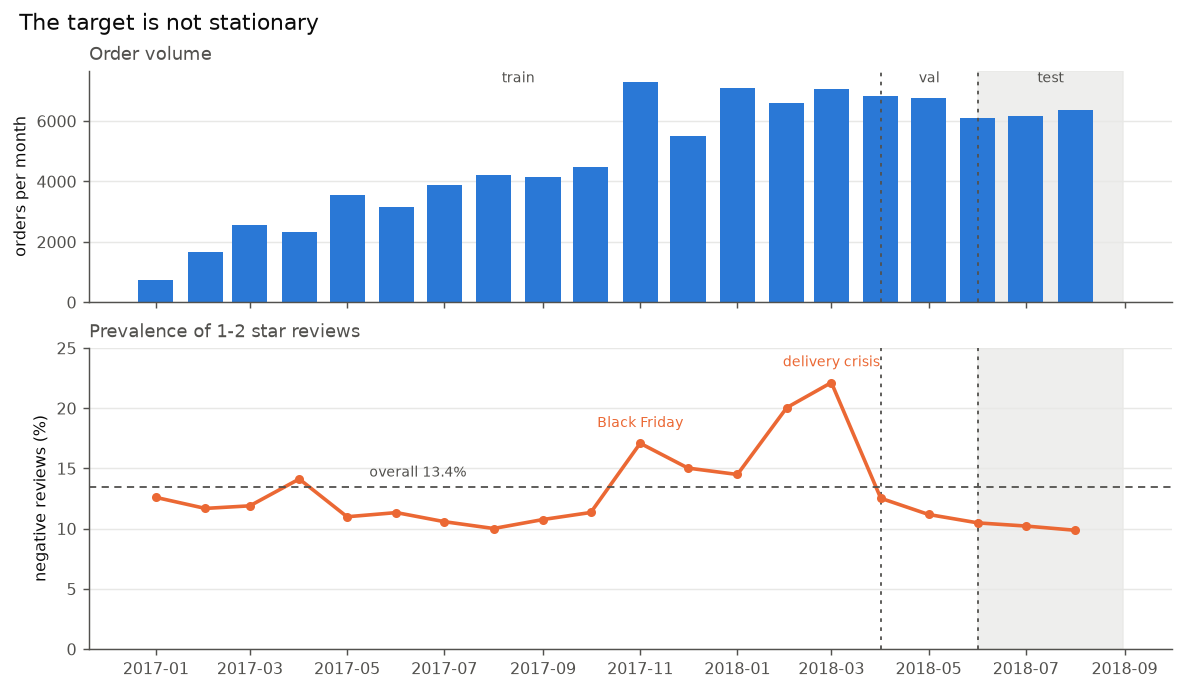

In [5]:
fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(9, 5.2), sharex=True, height_ratios=[1, 1.3], constrained_layout=True
)

x = monthly.index.to_timestamp()

# Two measures of different scale never share an axis - they get one panel each.
top.bar(x, monthly["orders"], width=22, color=BLUE)
top.set_ylabel("orders per month")
top.set_title("Order volume", loc="left", fontsize=10, color=MUTED)

bottom.plot(x, monthly["prevalence"] * 100, color=ORANGE, linewidth=2, marker="o", markersize=4)
bottom.axhline(spine["y"].mean() * 100, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
bottom.annotate(
    f"overall {spine['y'].mean():.1%}",
    xy=(pd.Timestamp("2017-05-15"), spine["y"].mean() * 100), xytext=(0, 6),
    textcoords="offset points", ha="left", fontsize=8, color=MUTED,
)
bottom.set_ylabel("negative reviews (%)")
bottom.set_title("Prevalence of 1-2 star reviews", loc="left", fontsize=10, color=MUTED)
bottom.set_ylim(0, 25)

# The split blocks: dotted dividers on both panels, plus a light wash over test
# to mark the block nothing is allowed to touch until the very end.
bounds = [x[0], config.VAL_START, config.TEST_START, x[-1] + pd.offsets.MonthEnd(0)]
for axis in (top, bottom):
    axis.grid(axis="y")
    axis.set_axisbelow(True)
    axis.axvspan(config.TEST_START, bounds[-1], color=BAND, alpha=0.7, zorder=0)
    for cut in (config.VAL_START, config.TEST_START):
        axis.axvline(cut, color=MUTED, linewidth=1, linestyle=(0, (2, 3)), zorder=1)

for start, end, name in zip(bounds[:-1], bounds[1:], config.SPLIT_ORDER, strict=True):
    top.text(
        start + (end - start) / 2, top.get_ylim()[1] * 0.95, name,
        ha="center", fontsize=8, color=MUTED,
    )

for label, month, dy in [("Black Friday", "2017-11", 9), ("delivery crisis", "2018-03", 9)]:
    bottom.annotate(
        label, xy=(pd.Timestamp(month), monthly.loc[month, "prevalence"] * 100),
        xytext=(0, dy), textcoords="offset points", ha="center", fontsize=8, color=ORANGE,
    )

fig.suptitle("The target is not stationary", fontsize=12, ha="left", x=0.01)
fig.savefig(config.FIGURES / "target_by_month.png", bbox_inches="tight")

## 2 · Why it moves

> **Leakage warning.** The next cell uses `order_delivered_customer_date`, the actual
> delivery date. That column is **forbidden as a feature**: it does not exist at t₀ or at t₁,
> and it predicts the target nearly perfectly. It is used here to *explain the past*, which is
> a different activity from building a predictor. `src/features.py` never touches it — the
> diagnosis stays confined to this notebook on purpose.

In [6]:
delivery = data.load_table("orders")[
    ["order_id", "order_estimated_delivery_date", "order_delivered_customer_date"]
]
diag = spine.merge(delivery, on="order_id", how="left")
diag["late"] = diag["order_delivered_customer_date"] > diag["order_estimated_delivery_date"]
diag["undelivered"] = diag["order_delivered_customer_date"].isna()

outcome = pd.DataFrame({
    "orders": [
        (~diag["late"] & ~diag["undelivered"]).sum(), diag["late"].sum(), diag["undelivered"].sum()
    ],
    "prevalence": [
        diag.loc[~diag["late"] & ~diag["undelivered"], "y"].mean(),
        diag.loc[diag["late"], "y"].mean(),
        diag.loc[diag["undelivered"], "y"].mean(),
    ],
}, index=["delivered on time", "delivered late", "never delivered"])
outcome.assign(prevalence=lambda d: (d["prevalence"] * 100).round(1))

,orders,prevalence
delivered on time,87888,9.2
delivered late,7658,54.0
never delivered,1090,69.4


monthly correlation: 0.872


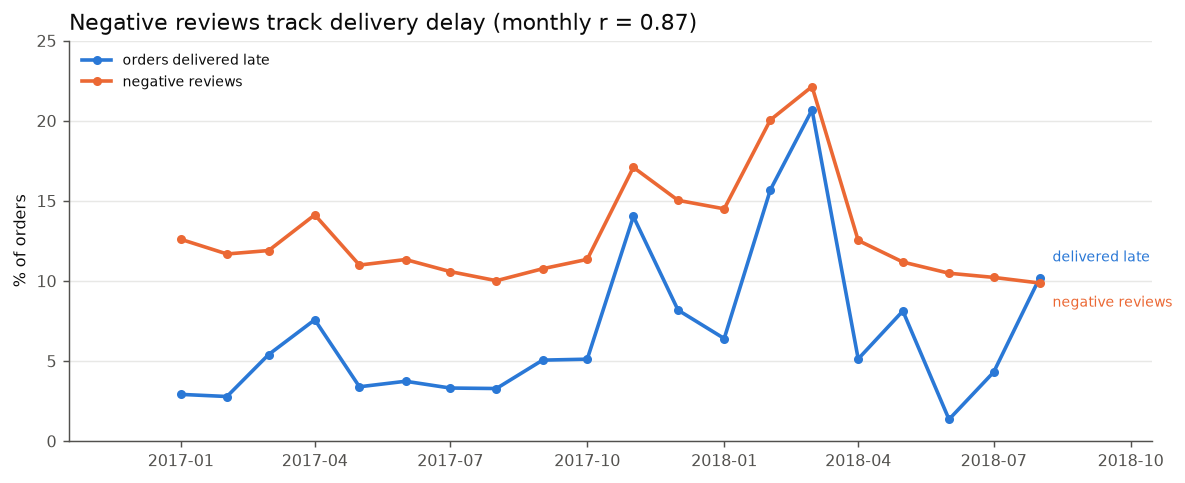

In [7]:
by_month = diag.groupby(diag["order_purchase_timestamp"].dt.to_period("M"), observed=True).agg(
    prevalence=("y", "mean"), late_rate=("late", "mean")
)
correlation = by_month["prevalence"].corr(by_month["late_rate"])

fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = by_month.index.to_timestamp()

# Both series are percentages of orders, so one shared axis is honest here.
ax.plot(x, by_month["late_rate"] * 100, color=BLUE, linewidth=2, marker="o", markersize=4,
        label="orders delivered late")
ax.plot(x, by_month["prevalence"] * 100, color=ORANGE, linewidth=2, marker="o", markersize=4,
        label="negative reviews")

# The two series converge in August, so the end labels are staggered rather than
# both sitting on the endpoint.
for series, color, name, dy in [
    ("late_rate", BLUE, "delivered late", 11),
    ("prevalence", ORANGE, "negative reviews", -11),
]:
    ax.annotate(name, xy=(x[-1], by_month[series].iloc[-1] * 100), xytext=(7, dy),
                textcoords="offset points", fontsize=8, color=color, va="center")

ax.set_ylabel("% of orders")
ax.set_ylim(0, 25)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.margins(x=0.13)
ax.legend(frameon=False, loc="upper left", fontsize=8)
ax.set_title(
    f"Negative reviews track delivery delay (monthly r = {correlation:.2f})",
    loc="left", fontsize=12,
)
fig.savefig(config.FIGURES / "prevalence_vs_delay.png", bbox_inches="tight")
print(f"monthly correlation: {correlation:.3f}")

## 3 · What this hands over

**The split (D-08).** Train `2017-01 .. 2018-03`, validation `2018-04 .. 2018-05`, test
`2018-06 .. 2018-08`. Both crises stay in training, so the model has seen a saturated
logistics network; validation and test share a calm regime, so a threshold calibrated on
validation still means something on test.

**The number to quote.** Test prevalence is **10.19%**, not the overall 13.42%. Every test
metric is read against that.

**For feature design (notebook 02).** Delay is the dominant driver — 54% prevalence when an
order arrives late against 9% when it does not. But delay is only *known* after the fact, so
the modelling job at t₀ and t₁ is to predict **delay risk** from what is visible at the time:
promised lead time, distance, seller history, carrier handover speed. The median order arrives
**13 days before** its promised date, so Olist's estimates carry a large buffer — losing that
buffer is itself the signal.